### DataViz

In [2]:
import pandas as pd
import numpy as np


In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [ ]:
from src.dataviz.core import DataViz, analyze

In [5]:
data = {
    'product': ['A', 'B', 'C', 'D', 'E'] * 40,
    'sales': np.random.normal(100, 25, 200),
    'price': np.random.uniform(10, 100, 200),
    'quantity': np.random.randint(1, 50, 200),
    'region': np.random.choice(['North', 'South', 'East', 'West'], 200),
    'rating': np.random.uniform(1, 5, 200),
    'category': np.random.choice(['Electronics', 'Clothing', 'Food'], 200)
}

In [6]:
# Add some missing values
data['sales'][np.random.choice(200, 10, replace=False)] = np.nan
data['rating'][np.random.choice(200, 5, replace=False)] = np.nan


In [7]:
df = pd.DataFrame(data)
# print("Sample dataset created!")
print(f"Shape: {df.shape}")

Shape: (200, 7)


In [8]:
dv = analyze(df)

In [9]:
dv.show()          # View data

,product,sales,price,quantity,region,rating,category
0,A,72.860140,41.138673,44,South,4.698913,Clothing
1,B,73.120032,33.718116,28,East,3.158405,Clothing
2,C,95.885660,37.539276,14,North,3.847615,Electronics
3,D,59.437745,62.803644,43,West,1.332826,Electronics
4,E,76.939759,97.719025,31,South,3.958147,Electronics
5,A,121.531451,84.502056,20,West,4.023337,Food
6,B,84.578156,97.180012,19,South,3.261097,Clothing
7,C,79.888161,33.217350,23,West,2.625537,Clothing
8,D,92.242754,67.865019,32,East,1.036619,Electronics
9,E,119.535377,67.162434,37,West,4.592725,Food


In [10]:
dv.insights()      # Get insights

In [11]:
# Check data quality issues
print("=" * 50)
print("DATA QUALITY SUMMARY")
print("=" * 50)
print(f"Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nData types:")
print(df.dtypes)
print(f"\nNumeric columns summary:")
print(df.describe())

DATA QUALITY SUMMARY
Missing values per column:
sales     10
rating     5
dtype: int64

Data types:
product      object
sales       float64
price       float64
quantity      int32
region       object
rating      float64
category     object
dtype: object

Numeric columns summary:
            sales       price    quantity      rating
count  190.000000  200.000000  200.000000  195.000000
mean    97.723571   56.942249   26.530000    3.042764
std     24.642019   25.082455   13.965467    1.133186
min     32.458671   12.585013    1.000000    1.006083
25%     79.475965   35.118838   16.000000    2.093659
50%     97.274828   55.133581   26.500000    3.118881
75%    113.248369   77.864825   39.000000    3.967497
max    171.065947   99.932705   49.000000    4.985077


In [12]:
dv.optimize()

⚡ Optimization Suggestions

💡 1. Optimize product
   Convert 'product' to category type for better performance

   Code:
   df['product'] = df['product'].astype('category')

💡 2. Optimize region
   Convert 'region' to category type for better performance

   Code:
   df['region'] = df['region'].astype('category')

💡 3. Optimize category
   Convert 'category' to category type for better performance

   Code:
   df['category'] = df['category'].astype('category')

💡 4. Vectorization Tips
   Use vectorized operations instead of loops for numeric columns

   Code:
   # Instead of: for i in range(len(df)): df.loc[i, 'new'] = df.loc[i, 'col'] * 2
# Use vectorized:
df['new_col'] = df['sales'] * 2



🎨 Generating Automatic Visualizations...

📊 Correlation Heatmap


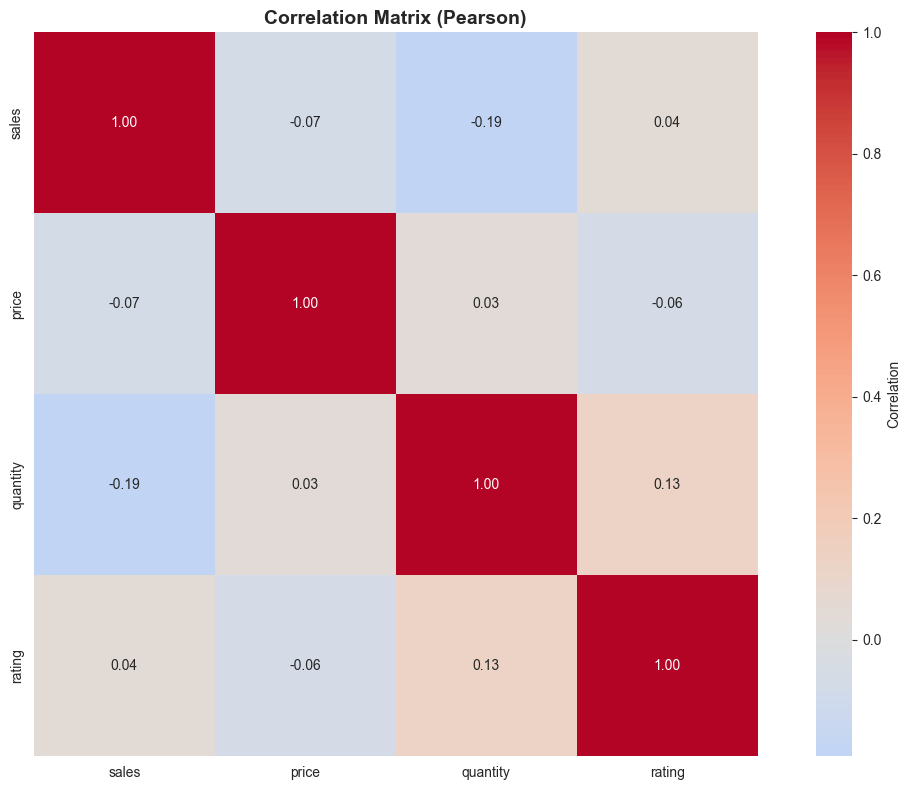

📊 Distribution of sales


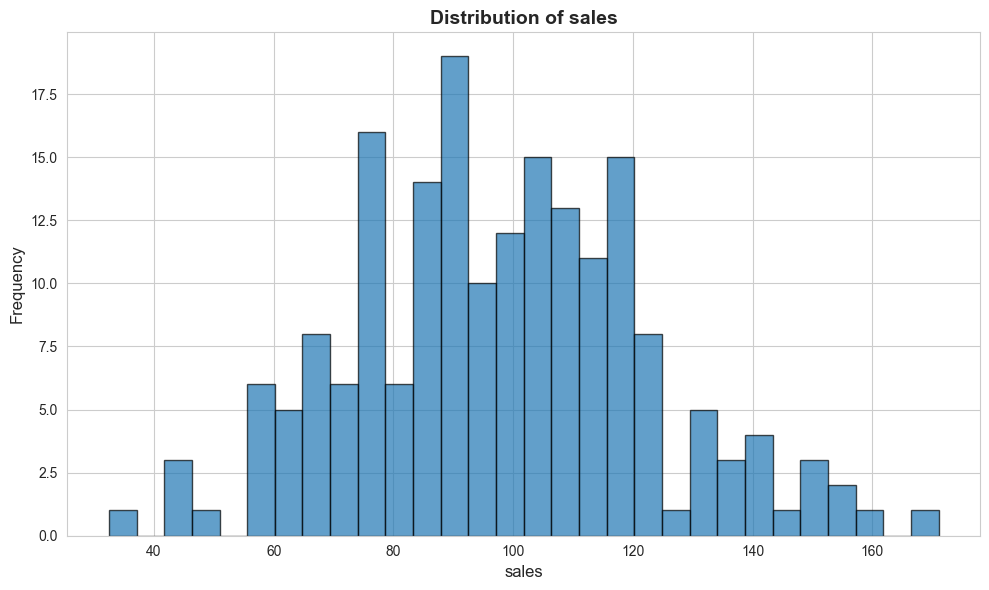

📊 Distribution of price


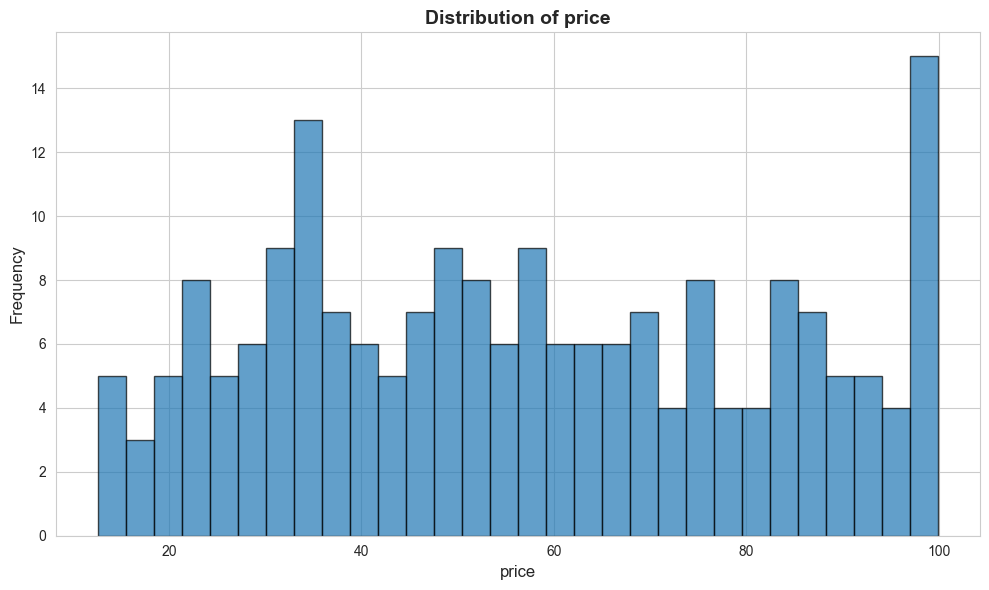

📊 Distribution of quantity


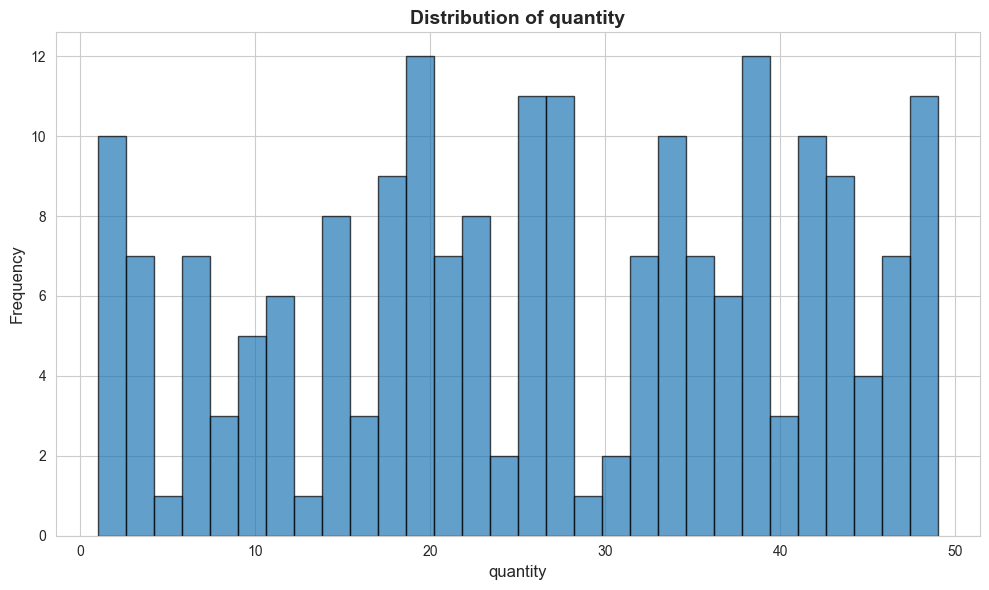

📊 Category Distribution of product


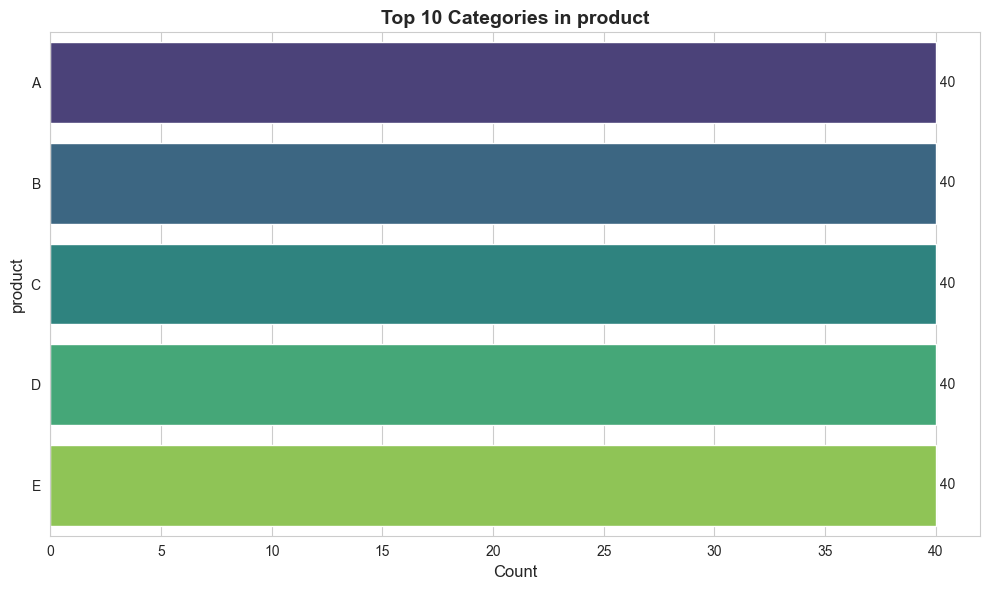

📊 Category Distribution of region


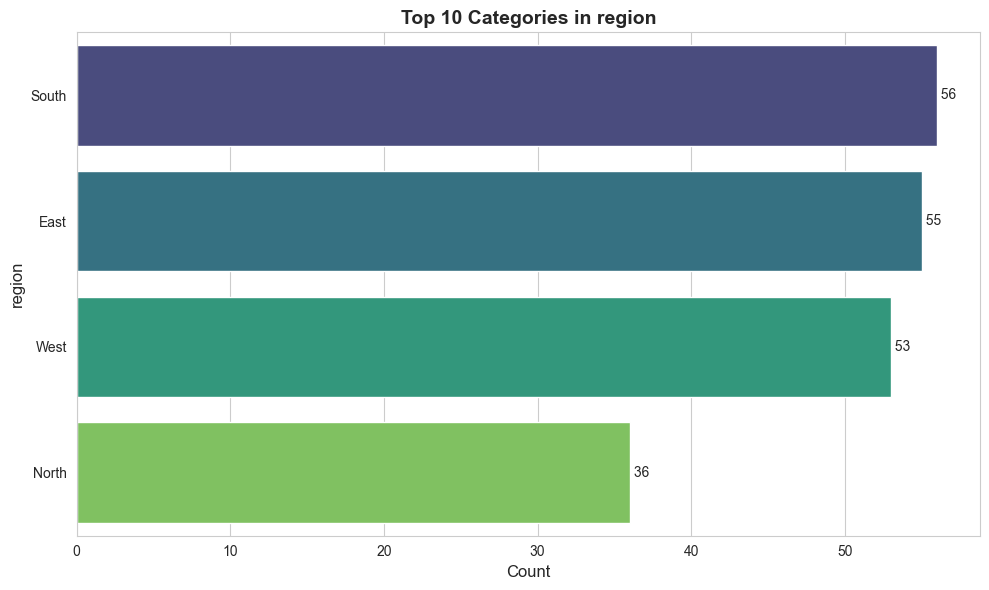

📊 Category Distribution of category


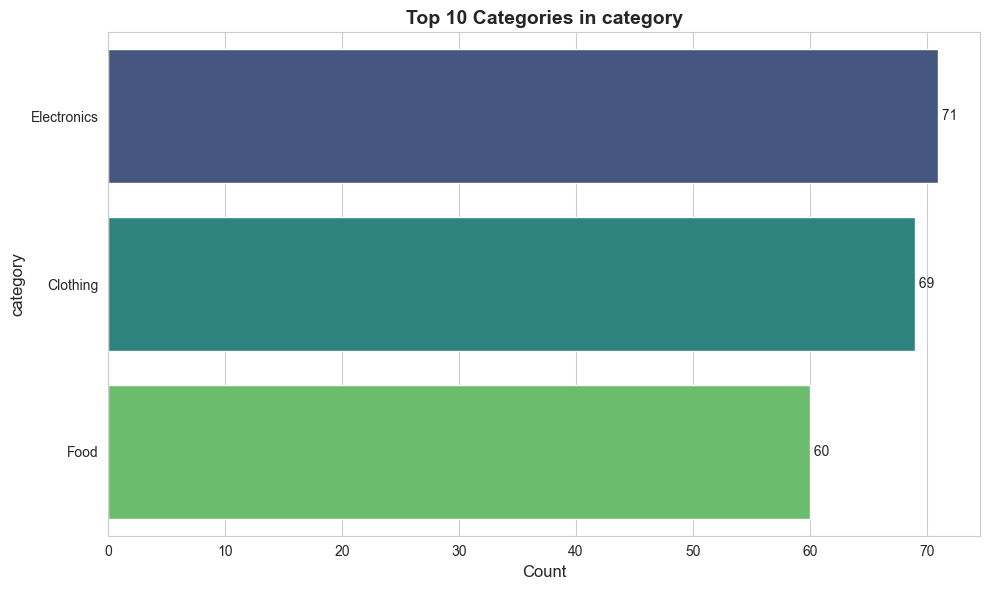

📊 Scatter Plot - sales vs quantity


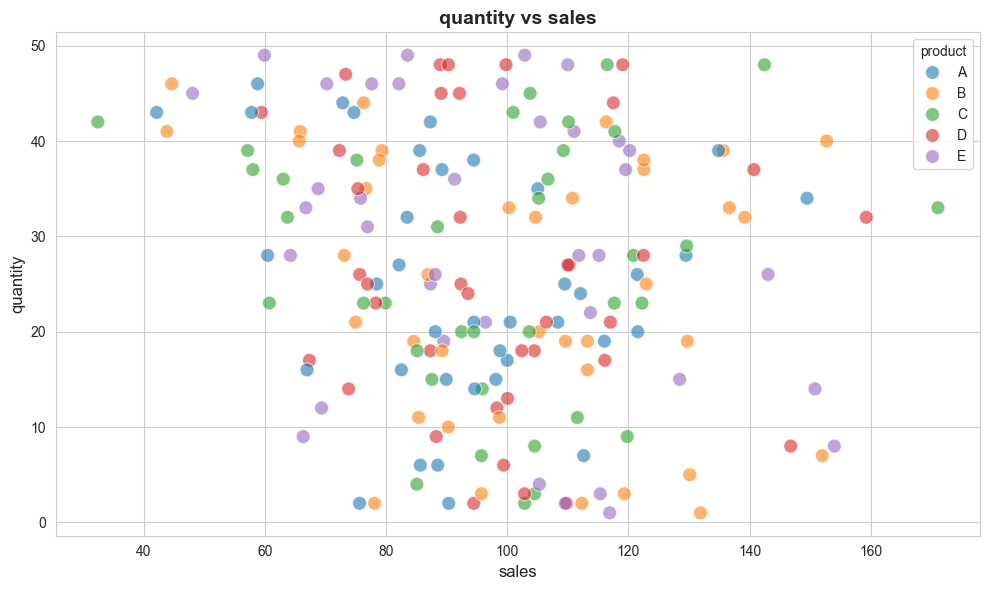

📊 Pairplot Analysis


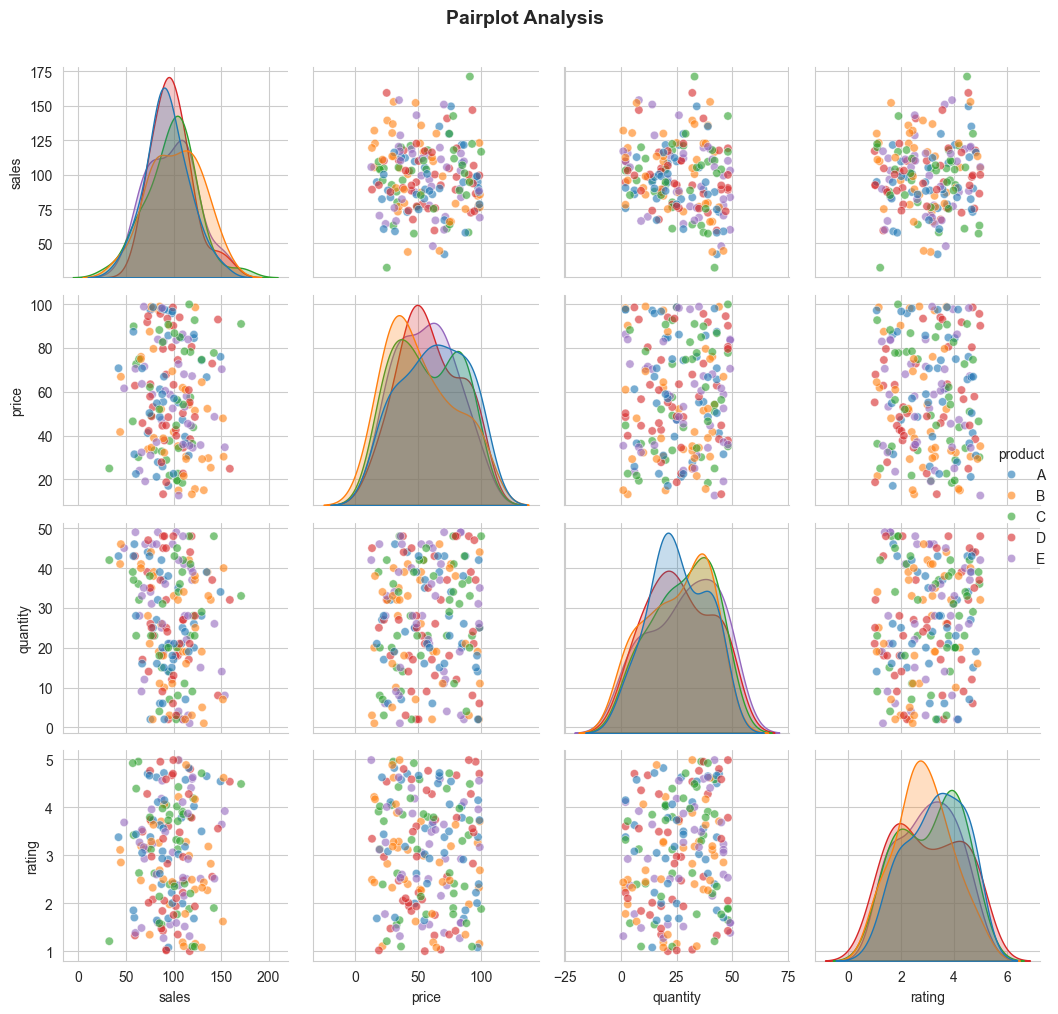


✅ Visualization complete! (9 charts generated)


In [13]:
dv.visualize()     # Chart recommendations

In [14]:
# Filter and analyze
dv_filtered = DataViz(df)
dv_filtered.filter(df['sales'] > 100)
print(f"Filtered dataset has {dv_filtered.df.shape[0]} rows")
dv_filtered.insights()

Filtered dataset has 88 rows


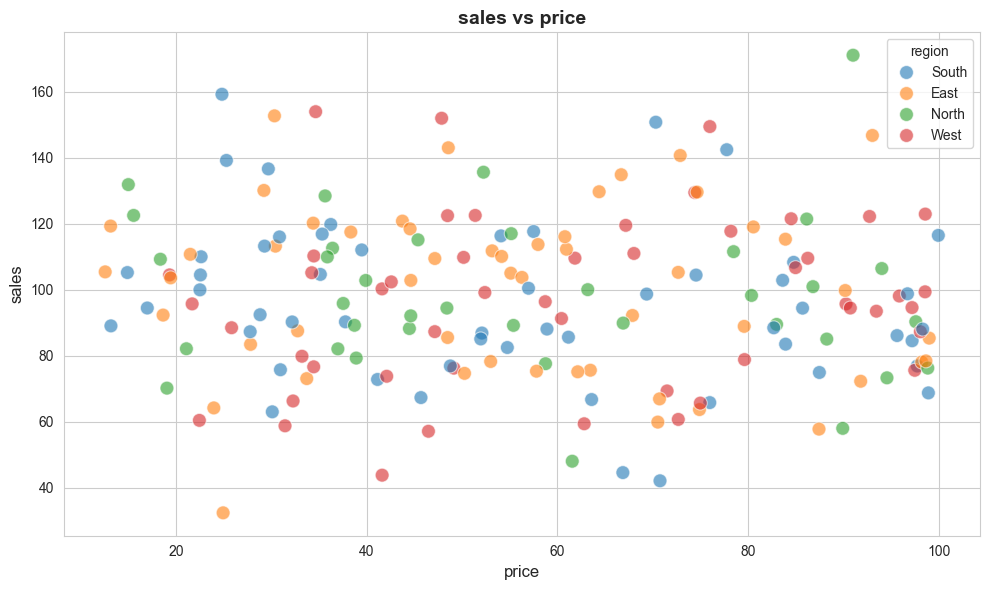

Comparing different regions:

South Region:
  Average Sales: $96.02
  Average Rating: 3.18
  Total Quantity: 1516

East Region:
  Average Sales: $100.07
  Average Rating: 3.04
  Total Quantity: 1556

North Region:
  Average Sales: $98.52
  Average Rating: 3.13
  Total Quantity: 940

West Region:
  Average Sales: $96.49
  Average Rating: 2.85
  Total Quantity: 1294


In [16]:
# Scatter with categorical hue
dv.plot_scatter('price', 'sales', hue='region')
# Compare different subsets
print("Comparing different regions:")
for region in df['region'].unique():
    subset = df[df['region'] == region]
    print(f"\n{region} Region:")
    print(f"  Average Sales: ${subset['sales'].mean():.2f}")
    print(f"  Average Rating: {subset['rating'].mean():.2f}")
    print(f"  Total Quantity: {subset['quantity'].sum()}")

In [17]:
print("Comparing different regions:")
for region in df['region'].unique():
    subset = df[df['region'] == region]
    print(f"\n{region} Region:")
    print(f"  Average Sales: ${subset['sales'].mean():.2f}")
    print(f"  Average Rating: {subset['rating'].mean():.2f}")
    print(f"  Total Quantity: {subset['quantity'].sum()}")

Comparing different regions:

South Region:
  Average Sales: $96.02
  Average Rating: 3.18
  Total Quantity: 1516

East Region:
  Average Sales: $100.07
  Average Rating: 3.04
  Total Quantity: 1556

North Region:
  Average Sales: $98.52
  Average Rating: 3.13
  Total Quantity: 940

West Region:
  Average Sales: $96.49
  Average Rating: 2.85
  Total Quantity: 1294


Pairplot for multivariate analysis:


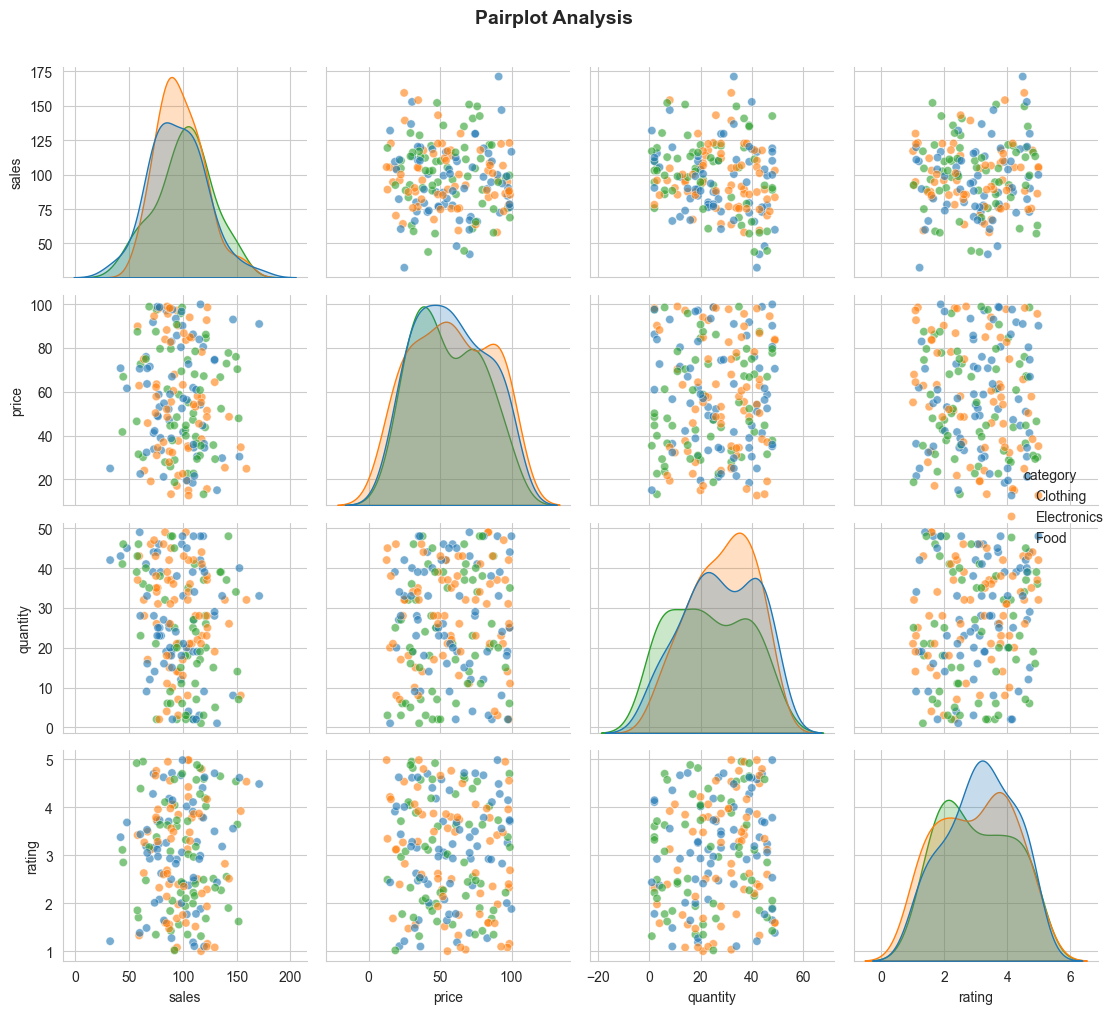

In [18]:
# Pairplot Analysis
print("Pairplot for multivariate analysis:")

# Select numeric columns for pairplot
dv.plot_pairplot(columns=['sales', 'price', 'quantity', 'rating'], hue='category')

In [19]:
# Use the pipeline

def analyze_dataset(dataframe, name="Dataset"):
    """Custom analysis function"""
    print(f"\n{'=' * 60}")
    print(f"ANALYSIS: {name}")
    print(f"{'=' * 60}")
    
    dv = DataViz(dataframe)
    dv.show()
    dv.insights()
    dv.visualize()
    
    return dv
    



ANALYSIS: Product Sales Data


,product,sales,price,quantity,region,rating,category
0,A,72.860140,41.138673,44,South,4.698913,Clothing
1,B,73.120032,33.718116,28,East,3.158405,Clothing
2,C,95.885660,37.539276,14,North,3.847615,Electronics
3,D,59.437745,62.803644,43,West,1.332826,Electronics
4,E,76.939759,97.719025,31,South,3.958147,Electronics
5,A,121.531451,84.502056,20,West,4.023337,Food
6,B,84.578156,97.180012,19,South,3.261097,Clothing
7,C,79.888161,33.217350,23,West,2.625537,Clothing
8,D,92.242754,67.865019,32,East,1.036619,Electronics
9,E,119.535377,67.162434,37,West,4.592725,Food


🎨 Generating Automatic Visualizations...

📊 Correlation Heatmap


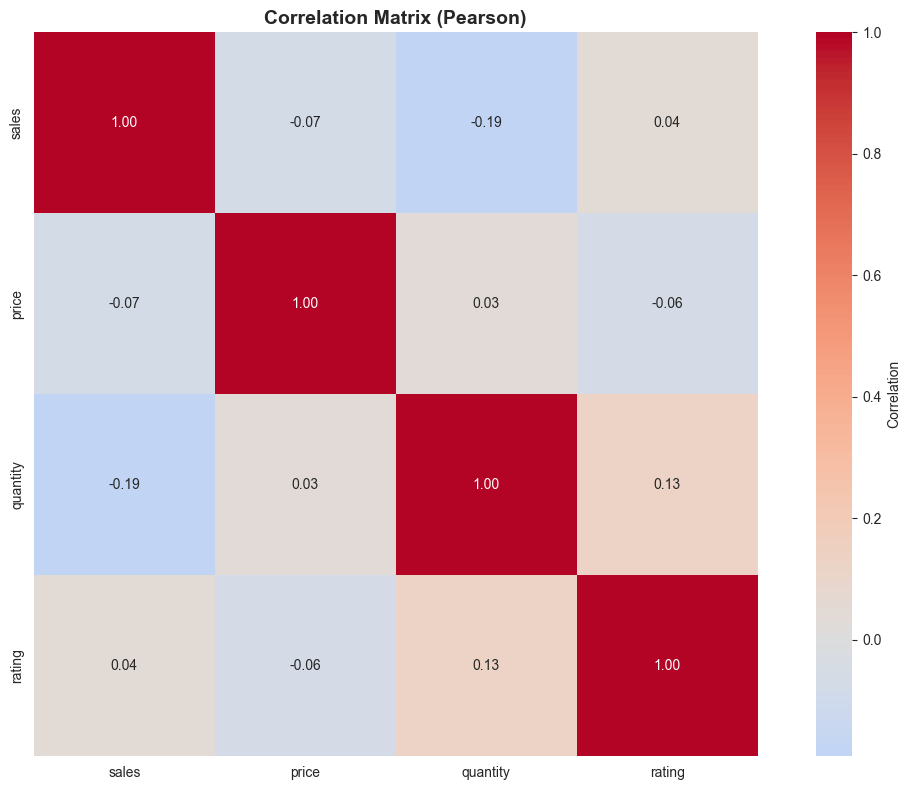

📊 Distribution of sales


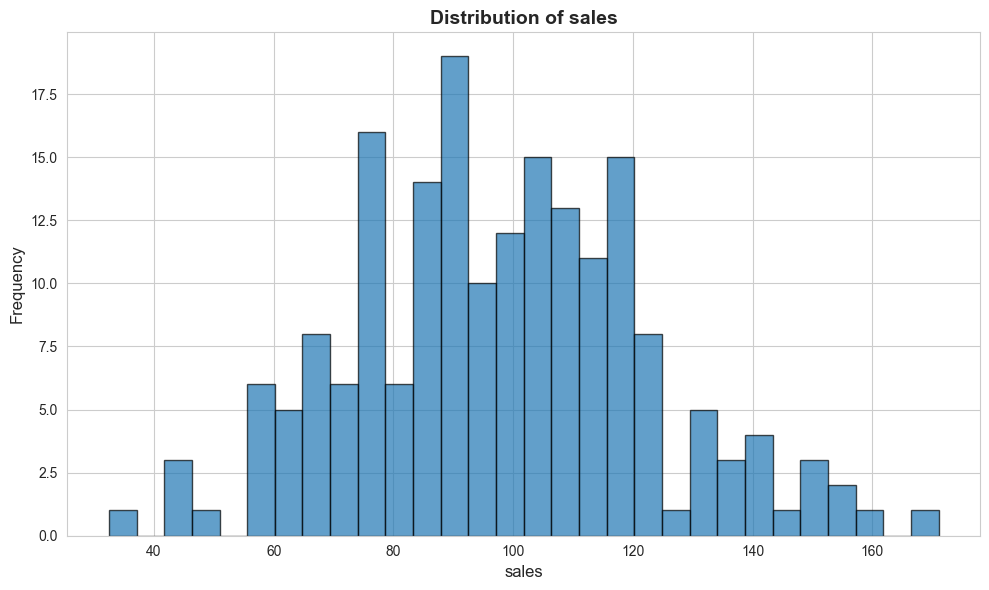

📊 Distribution of price


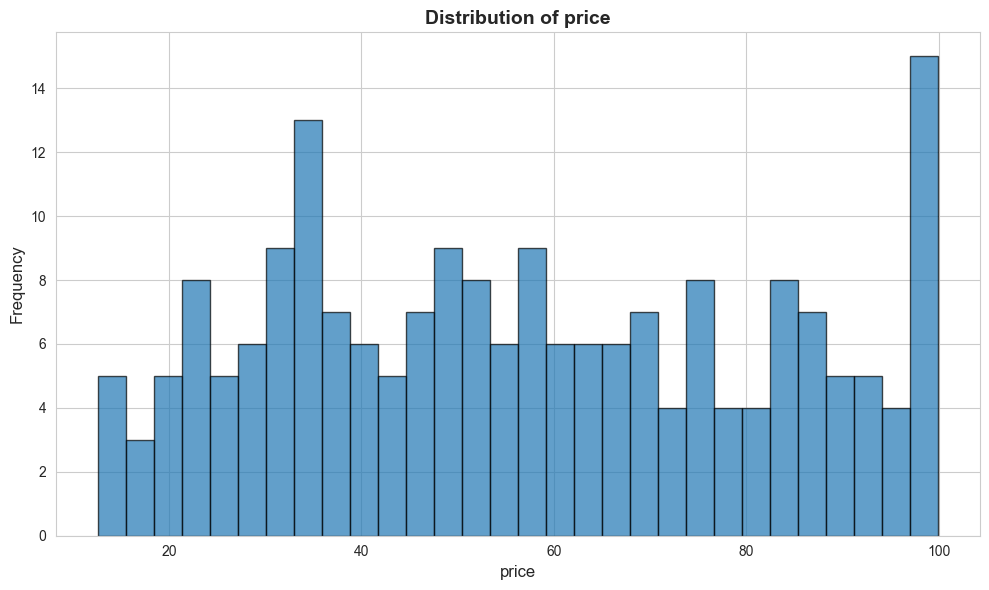

📊 Distribution of quantity


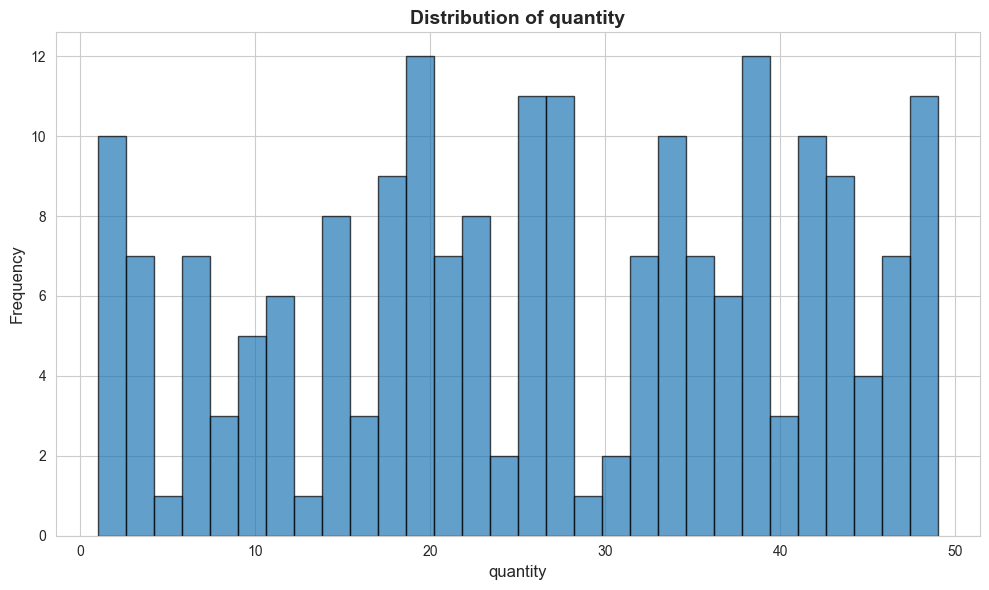

📊 Category Distribution of product


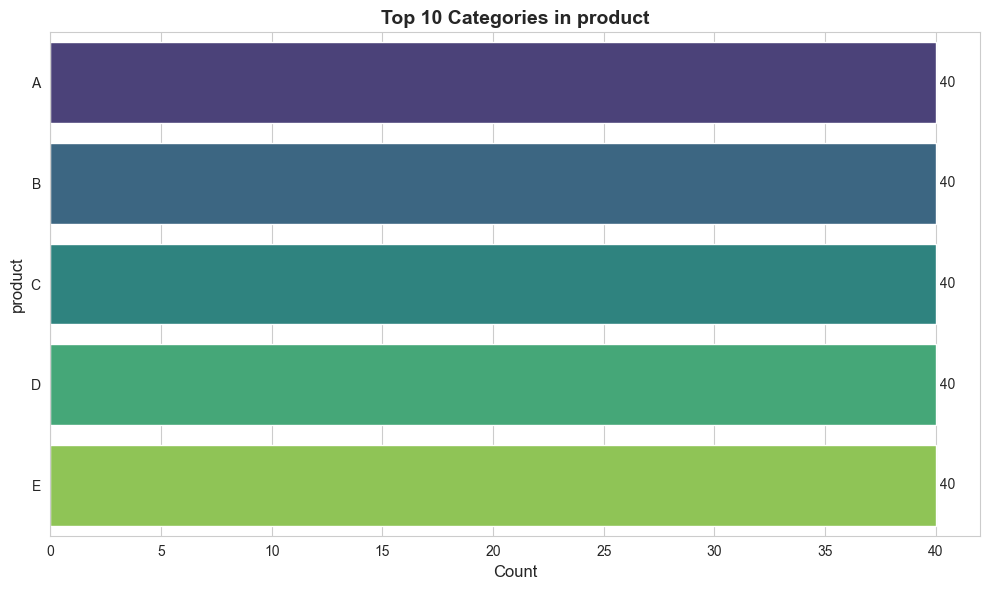

📊 Category Distribution of region


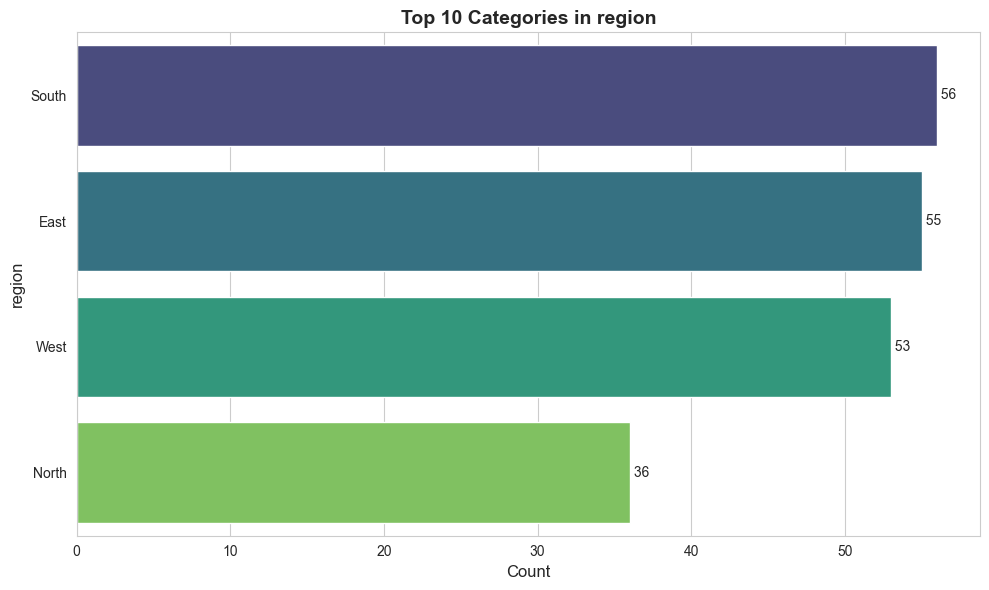

📊 Category Distribution of category


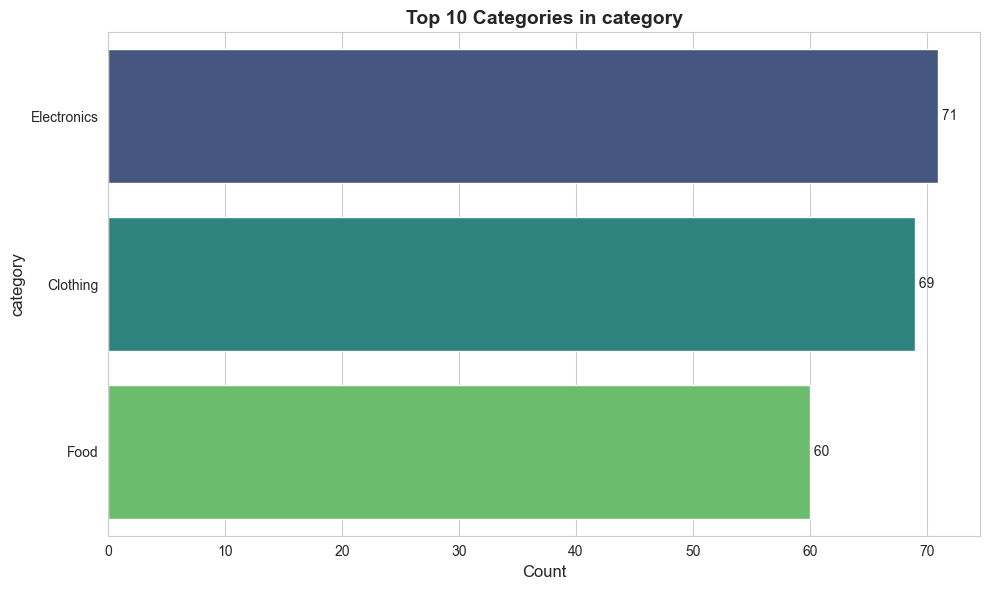

📊 Scatter Plot - sales vs quantity


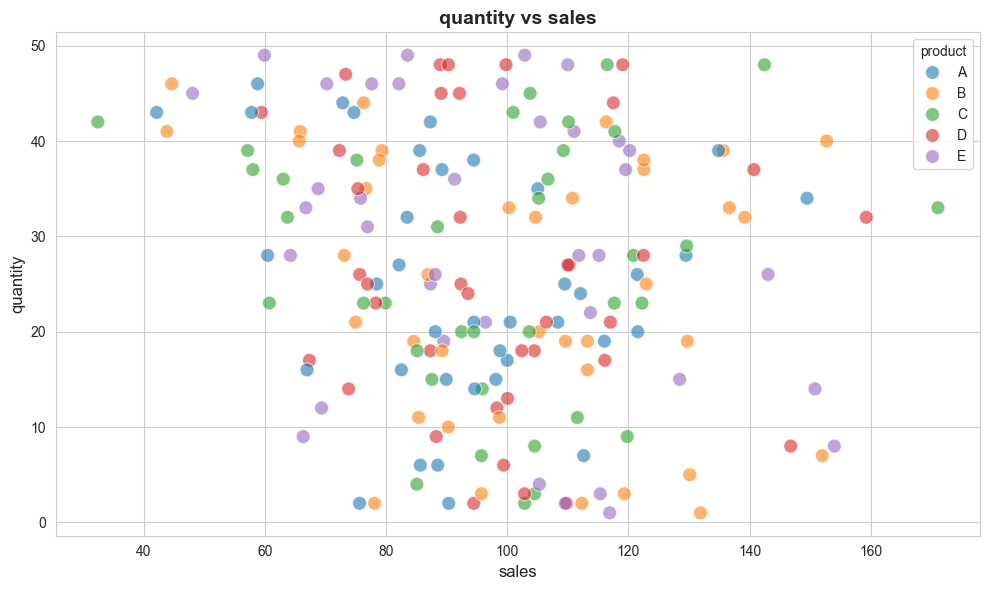

📊 Pairplot Analysis


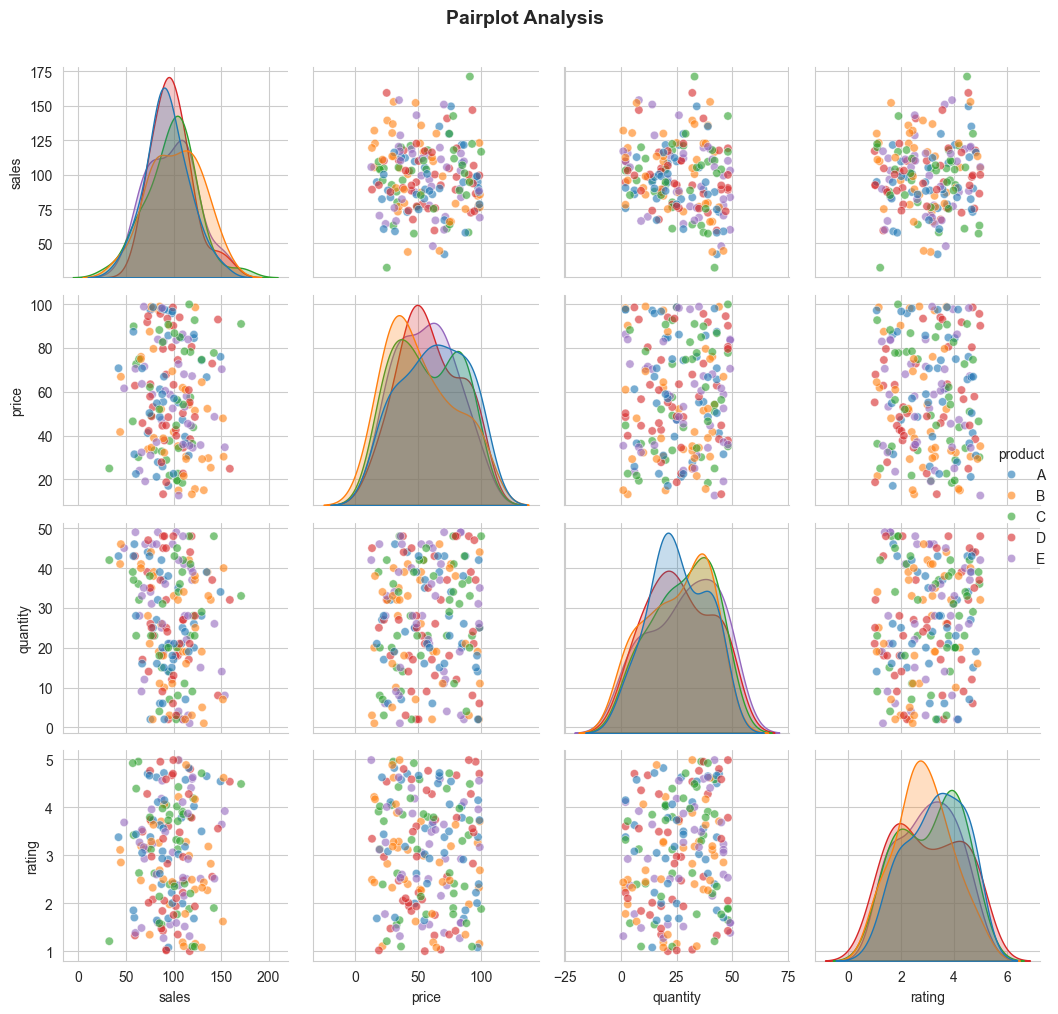


✅ Visualization complete! (9 charts generated)


In [20]:
result = analyze_dataset(df, "Product Sales Data")

In [21]:
def extract_insights_data(dv_obj):
    """Extract insights as structured data"""
    insights_list = []
    
    # Basic stats
    insights_list.append({
        'metric': 'row_count',
        'value': dv_obj.df.shape[0]
    })
    insights_list.append({
        'metric': 'column_count',
        'value': dv_obj.df.shape[1]
    })
    
    # Missing values
    missing = dv_obj.df.isnull().sum()
    for col in missing[missing > 0].index:
        insights_list.append({
            'metric': f'missing_{col}',
            'value': missing[col]
        })
    
    return pd.DataFrame(insights_list)

insights_df = extract_insights_data(dv)
print("Extracted Insights:")
print(insights_df)

Extracted Insights:
           metric  value
0       row_count    200
1    column_count      7
2   missing_sales     10
3  missing_rating      5


In [22]:
# Example of processing multiple datasets
datasets = {
    'Sales': df,
    'Marketing': sales_data,
}

print("Batch Analysis Report")
print("=" * 60)

for name, data in datasets.items():
    print(f"\n{name}:")
    dv_temp = DataViz(data)
    print(f"  Rows: {dv_temp.df.shape[0]}")
    print(f"  Columns: {dv_temp.df.shape[1]}")
    print(f"  Missing: {dv_temp.df.isnull().sum().sum()}")


NameError: name 'sales_data' is not defined

In [ ]:
# Integration with Pandas
print("Pandas Integration Example:")
print(f"Original shape: {dv.df.shape}")

# Apply pandas operations
dv.df['profit'] = dv.df['sales'] - (dv.df['price'] * 0.6)
dv.df['profit_margin'] = dv.df['profit'] / dv.df['sales']

print(f"After adding columns: {dv.df.shape}")
dv.insights()

In [23]:
# Perform operations (these get tracked)
dv.filter(df['price'] > 25, "df['price'] > 10")
dv.sort_values('sales', ascending=False)
# dv.drop_missing(['col'])

In [24]:
dv.generate_code()

📄 Generated Pandas Code:



# Load your data
df = pd.read_csv('your_data.csv')

import pandas as pd
import numpy as np

df = df[df['price'] > 10]
df = df.sort_values('sales', ascending=False)

"# Load your data\ndf = pd.read_csv('your_data.csv')\n\nimport pandas as pd\nimport numpy as np\n\ndf = df[df['price'] > 10]\ndf = df.sort_values('sales', ascending=False)"

In [25]:
# dv.export_analysis_code('my_analysis.py')

In [26]:
dv.suggest_charts()

📊 Suggested Visualizations

1. Distribution of sales
   Code:
   import matplotlib.pyplot as plt
   
   plt.figure(figsize=(10, 6))
   plt.hist(df['sales'], bins=30, edgecolor='black', alpha=0.7)
   plt.xlabel('sales')
   plt.ylabel('Frequency')
   plt.title(f'Distribution of sales')
   plt.grid(True, alpha=0.3)
   plt.show()

2. Distribution of price
   Code:
   import matplotlib.pyplot as plt
   
   plt.figure(figsize=(10, 6))
   plt.hist(df['price'], bins=30, edgecolor='black', alpha=0.7)
   plt.xlabel('price')
   plt.ylabel('Frequency')
   plt.title(f'Distribution of price')
   plt.grid(True, alpha=0.3)
   plt.show()

3. Distribution of quantity
   Code:
   import matplotlib.pyplot as plt
   
   plt.figure(figsize=(10, 6))
   plt.hist(df['quantity'], bins=30, edgecolor='black', alpha=0.7)
   plt.xlabel('quantity')
   plt.ylabel('Frequency')
   plt.title(f'Distribution of quantity')
   plt.grid(True, alpha=0.3)
   plt.show()

4. Frequency of product
   Code:
   import matplotlib.pyp

[{'title': 'Distribution of sales',
  'code': "import matplotlib.pyplot as plt\n\nplt.figure(figsize=(10, 6))\nplt.hist(df['sales'], bins=30, edgecolor='black', alpha=0.7)\nplt.xlabel('sales')\nplt.ylabel('Frequency')\nplt.title(f'Distribution of sales')\nplt.grid(True, alpha=0.3)\nplt.show()"},
 {'title': 'Distribution of price',
  'code': "import matplotlib.pyplot as plt\n\nplt.figure(figsize=(10, 6))\nplt.hist(df['price'], bins=30, edgecolor='black', alpha=0.7)\nplt.xlabel('price')\nplt.ylabel('Frequency')\nplt.title(f'Distribution of price')\nplt.grid(True, alpha=0.3)\nplt.show()"},
 {'title': 'Distribution of quantity',
  'code': "import matplotlib.pyplot as plt\n\nplt.figure(figsize=(10, 6))\nplt.hist(df['quantity'], bins=30, edgecolor='black', alpha=0.7)\nplt.xlabel('quantity')\nplt.ylabel('Frequency')\nplt.title(f'Distribution of quantity')\nplt.grid(True, alpha=0.3)\nplt.show()"},
 {'title': 'Frequency of product',
  'code': "import matplotlib.pyplot as plt\n\nvalue_counts = d

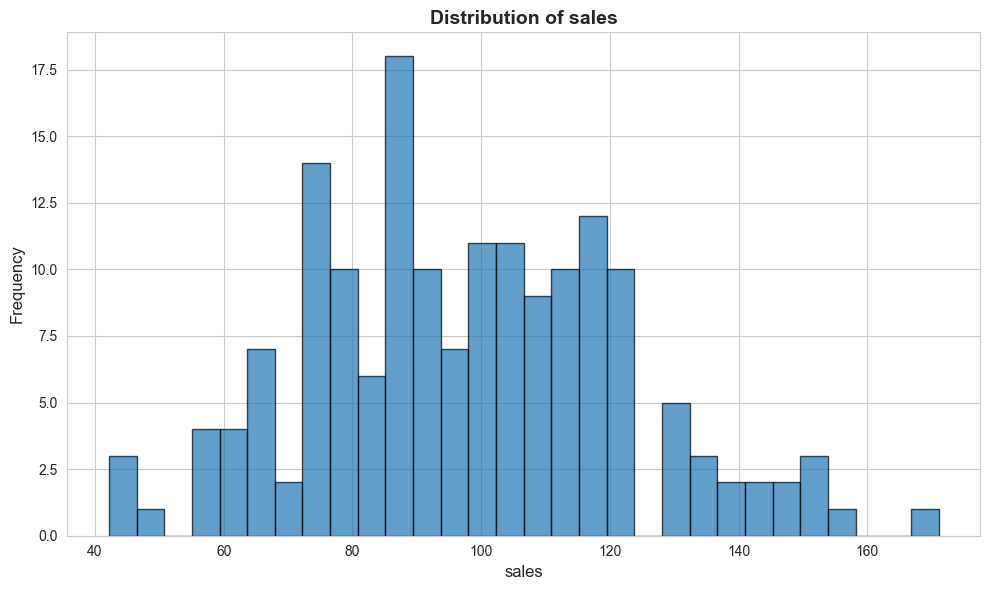

ModuleNotFoundError: No module named 'scipy'

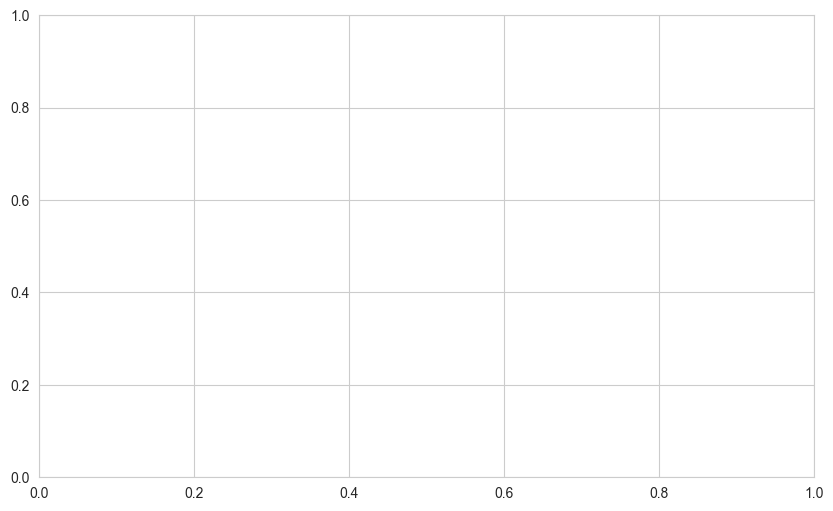

In [27]:
# Histogram
dv.plot_distribution('sales', kind='hist')

# KDE plot
dv.plot_distribution('sales', kind='kde')

# Box plot (great for outlier detection)
dv.plot_distribution('sales', kind='box')

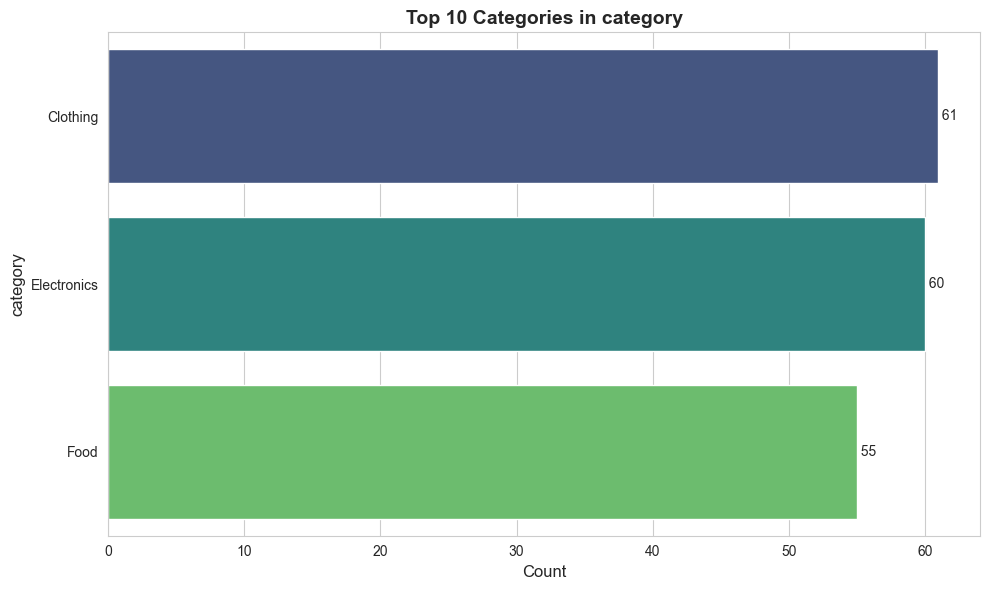

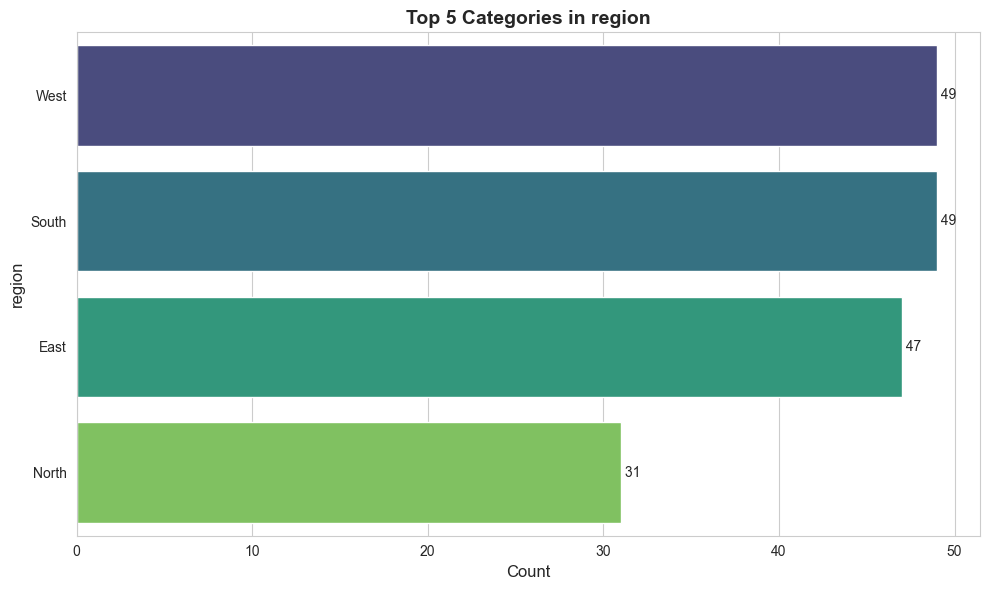

In [28]:
# Show all categories
dv.plot_categorical('category')

# Show only top 5 categories
dv.plot_categorical('region', top_n=5)

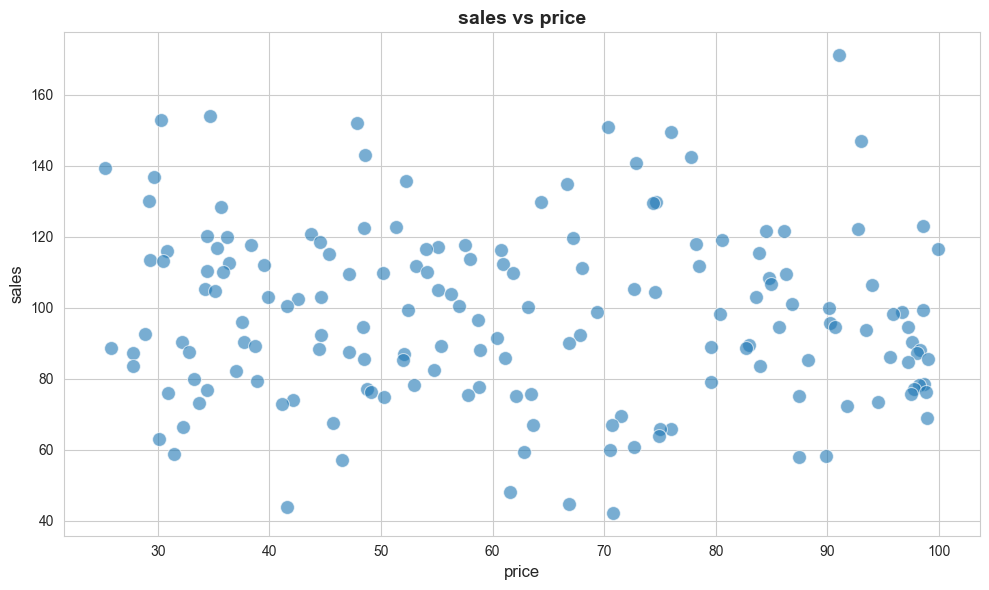

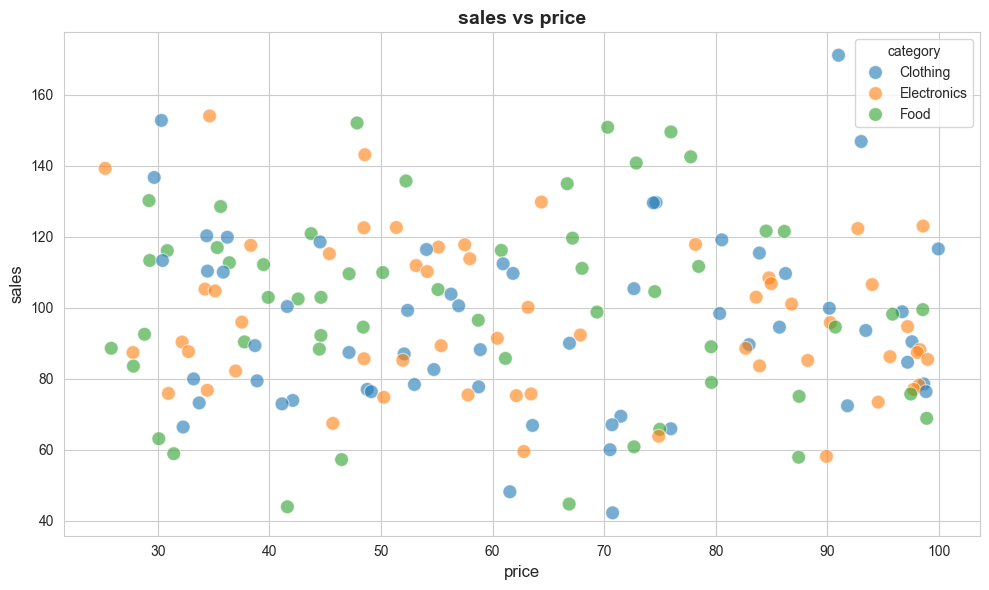

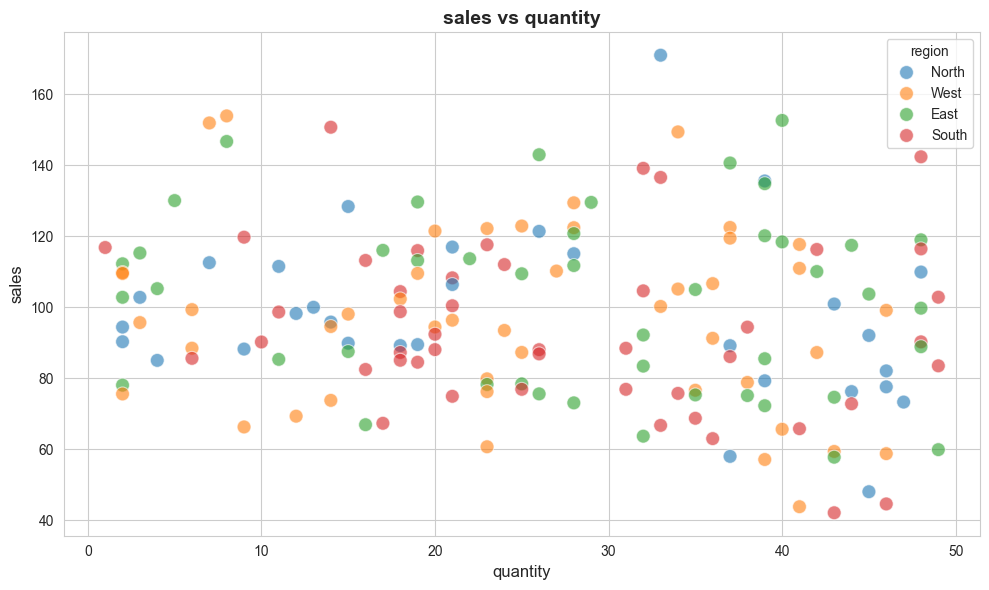

In [29]:
# Basic scatter plot
dv.plot_scatter('price', 'sales')

# Scatter plot with categorical color encoding
dv.plot_scatter('price', 'sales', hue='category')

# Three variables: x, y, and color
dv.plot_scatter('quantity', 'sales', hue='region')

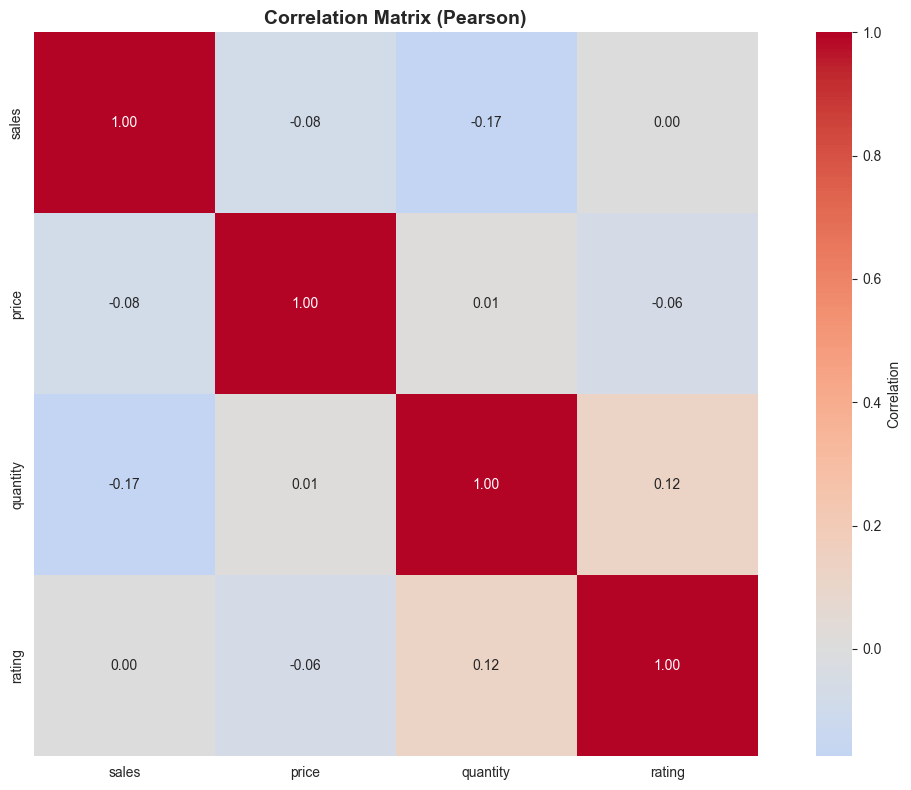

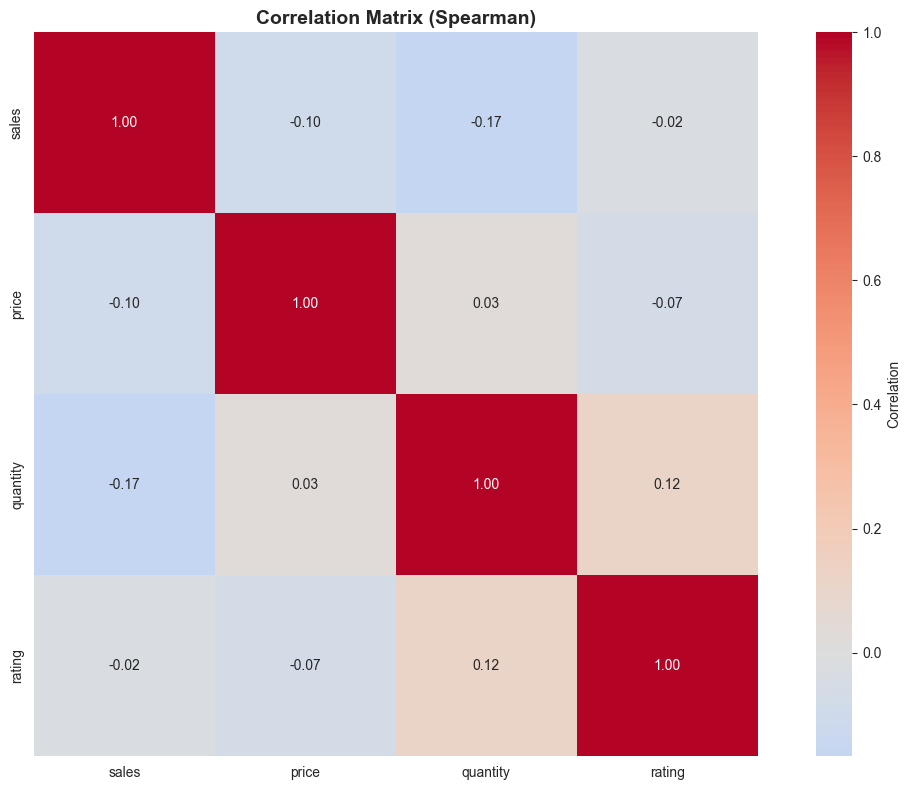

ModuleNotFoundError: No module named 'scipy'

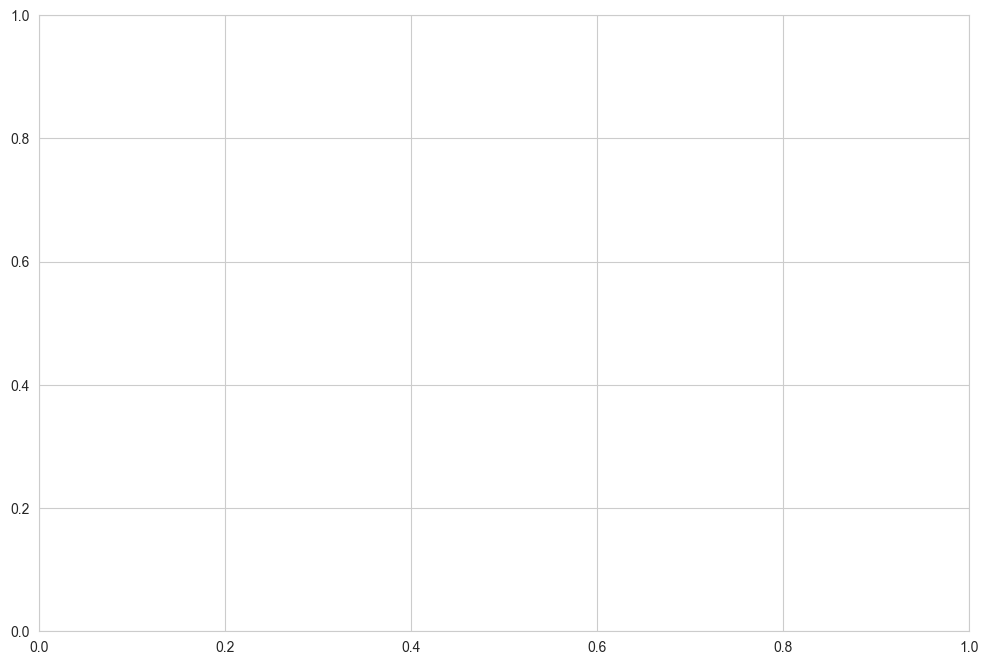

In [30]:
# Pearson correlation (default - linear relationships)
dv.plot_correlation(method='pearson')

# Spearman correlation (monotonic relationships)
dv.plot_correlation(method='spearman')

# Kendall correlation (ordinal relationships)
dv.plot_correlation(method='kendall')

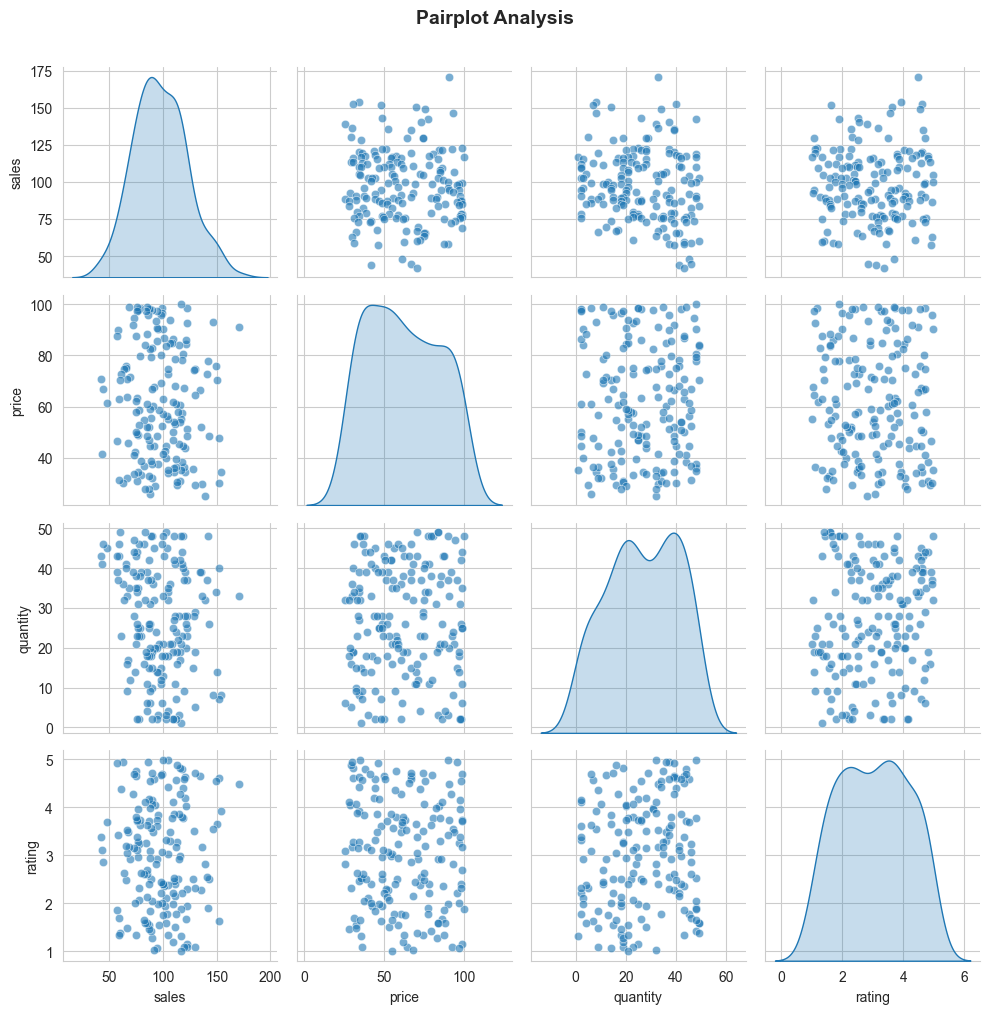

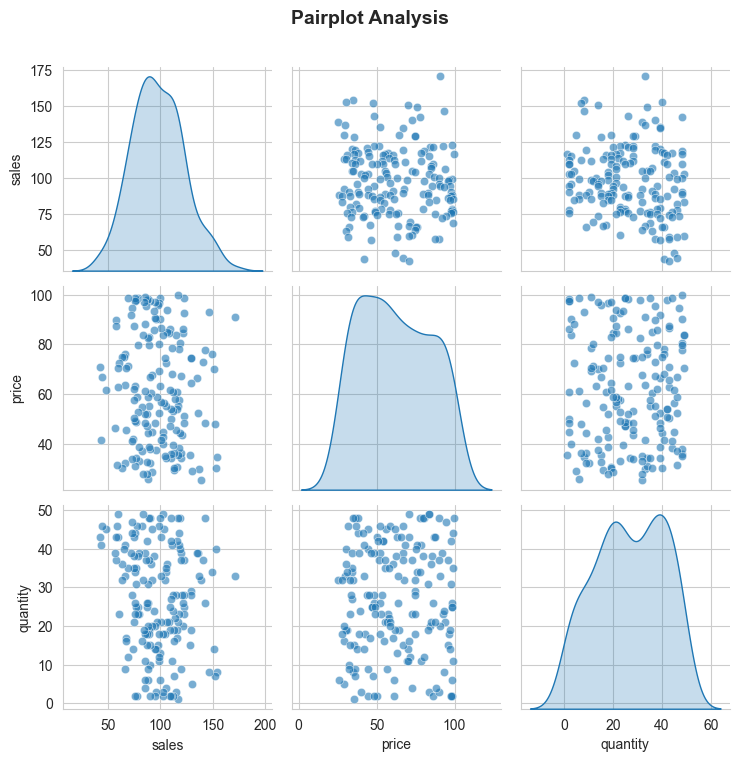

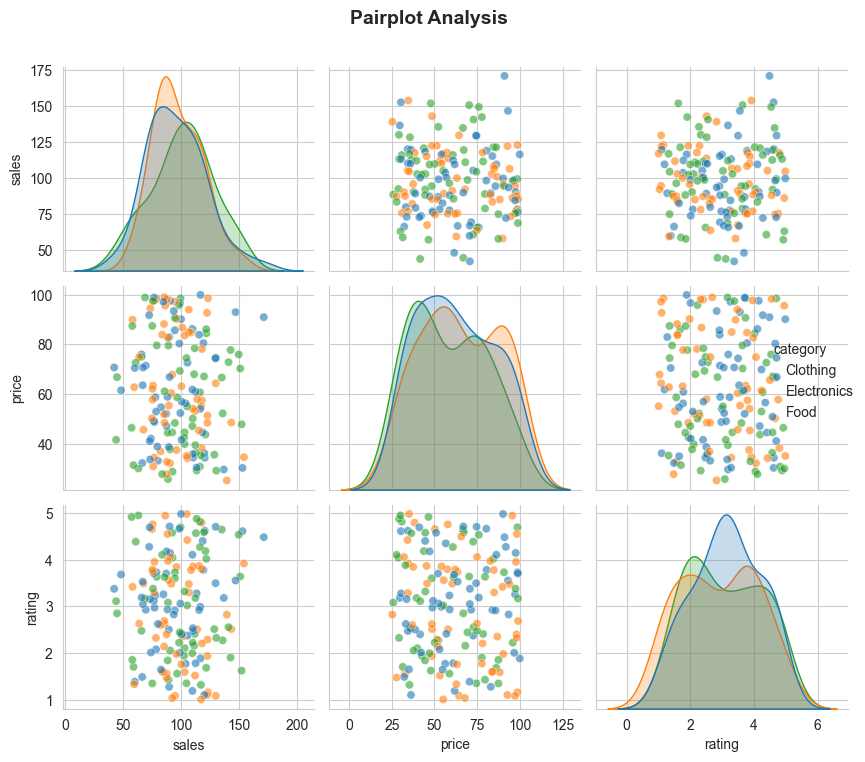

In [31]:
# Pairplot of all numeric columns (limited to first 4)
dv.plot_pairplot()

# Pairplot of specific columns
dv.plot_pairplot(columns=['sales', 'price', 'quantity'])

# Pairplot with categorical color encoding
dv.plot_pairplot(columns=['sales', 'price', 'rating'], hue='category')

In [33]:
# Time series data
print("Time Series Analysis")

# Create time series data
ts_df = pd.DataFrame({
    'date': pd.date_range('2024-01-01', periods=365, freq='D'),
    'revenue': np.random.normal(10000, 1000, 365) + np.linspace(0, 5000, 365),
    'customers': np.random.randint(100, 300, 365),
    'conversion': np.random.uniform(0.01, 0.05, 365)
})

# dv_ts = DataViz(ts_df)


Time Series Analysis


In [34]:
dv_ts = analyze(ts_df)

In [36]:
dv_ts.show(n=5)

,date,revenue,customers,conversion
0,2024-01-01,9964.089602,109,0.034394
1,2024-01-02,9612.380593,102,0.013990
2,2024-01-03,9422.935876,123,0.048491
3,2024-01-04,10690.460031,210,0.030859
4,2024-01-05,11617.826737,193,0.021275


In [38]:
dv_ts.insights()

In [39]:
dv_ts.optimize()

⚡ Optimization Suggestions

💡 1. Vectorization Tips
   Use vectorized operations instead of loops for numeric columns

   Code:
   # Instead of: for i in range(len(df)): df.loc[i, 'new'] = df.loc[i, 'col'] * 2
# Use vectorized:
df['new_col'] = df['revenue'] * 2



In [42]:
dv_ts.suggest_charts()

📊 Suggested Visualizations

1. Distribution of revenue
   Code:
   import matplotlib.pyplot as plt
   
   plt.figure(figsize=(10, 6))
   plt.hist(df['revenue'], bins=30, edgecolor='black', alpha=0.7)
   plt.xlabel('revenue')
   plt.ylabel('Frequency')
   plt.title(f'Distribution of revenue')
   plt.grid(True, alpha=0.3)
   plt.show()

2. Distribution of customers
   Code:
   import matplotlib.pyplot as plt
   
   plt.figure(figsize=(10, 6))
   plt.hist(df['customers'], bins=30, edgecolor='black', alpha=0.7)
   plt.xlabel('customers')
   plt.ylabel('Frequency')
   plt.title(f'Distribution of customers')
   plt.grid(True, alpha=0.3)
   plt.show()

3. Distribution of conversion
   Code:
   import matplotlib.pyplot as plt
   
   plt.figure(figsize=(10, 6))
   plt.hist(df['conversion'], bins=30, edgecolor='black', alpha=0.7)
   plt.xlabel('conversion')
   plt.ylabel('Frequency')
   plt.title(f'Distribution of conversion')
   plt.grid(True, alpha=0.3)
   plt.show()

4. revenue vs customers
 

[{'title': 'Distribution of revenue',
  'code': "import matplotlib.pyplot as plt\n\nplt.figure(figsize=(10, 6))\nplt.hist(df['revenue'], bins=30, edgecolor='black', alpha=0.7)\nplt.xlabel('revenue')\nplt.ylabel('Frequency')\nplt.title(f'Distribution of revenue')\nplt.grid(True, alpha=0.3)\nplt.show()"},
 {'title': 'Distribution of customers',
  'code': "import matplotlib.pyplot as plt\n\nplt.figure(figsize=(10, 6))\nplt.hist(df['customers'], bins=30, edgecolor='black', alpha=0.7)\nplt.xlabel('customers')\nplt.ylabel('Frequency')\nplt.title(f'Distribution of customers')\nplt.grid(True, alpha=0.3)\nplt.show()"},
 {'title': 'Distribution of conversion',
  'code': "import matplotlib.pyplot as plt\n\nplt.figure(figsize=(10, 6))\nplt.hist(df['conversion'], bins=30, edgecolor='black', alpha=0.7)\nplt.xlabel('conversion')\nplt.ylabel('Frequency')\nplt.title(f'Distribution of conversion')\nplt.grid(True, alpha=0.3)\nplt.show()"},
 {'title': 'revenue vs customers',
  'code': "import matplotlib.p

🎨 Generating Automatic Visualizations...

📊 Correlation Heatmap


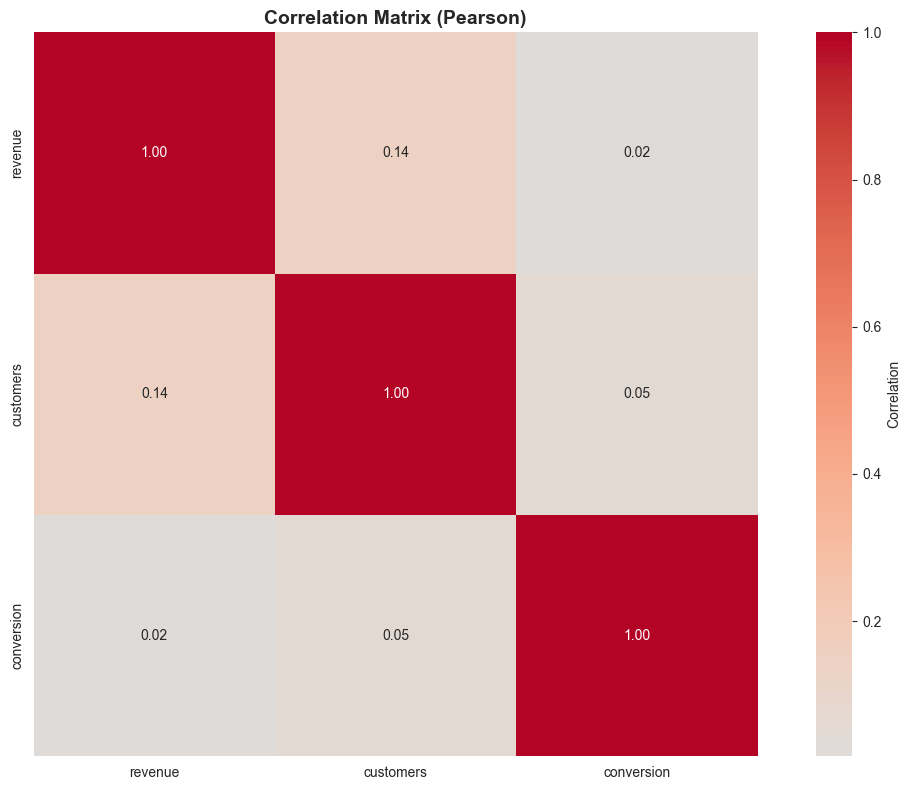

📊 Distribution of revenue


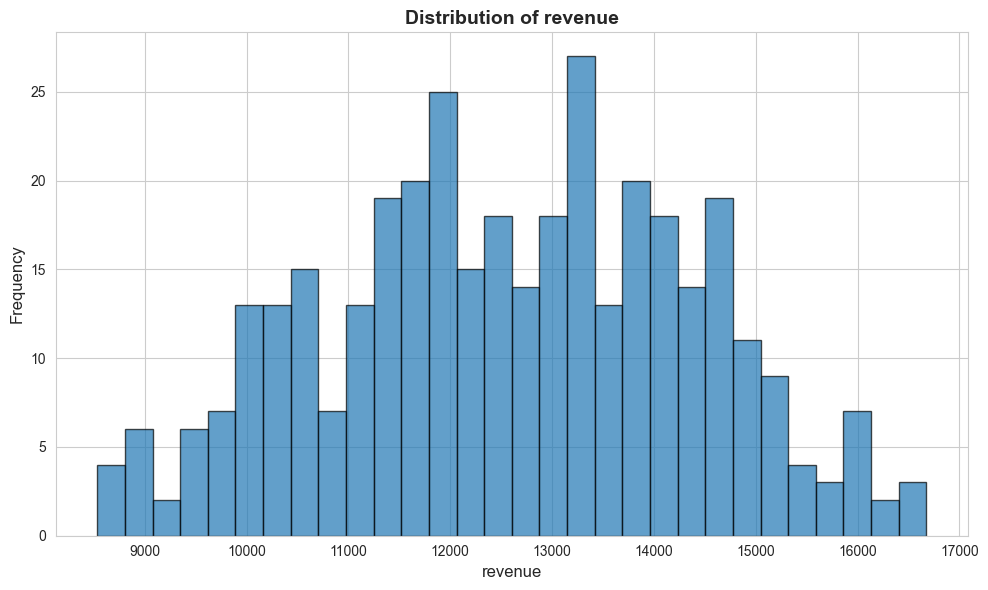

📊 Distribution of customers


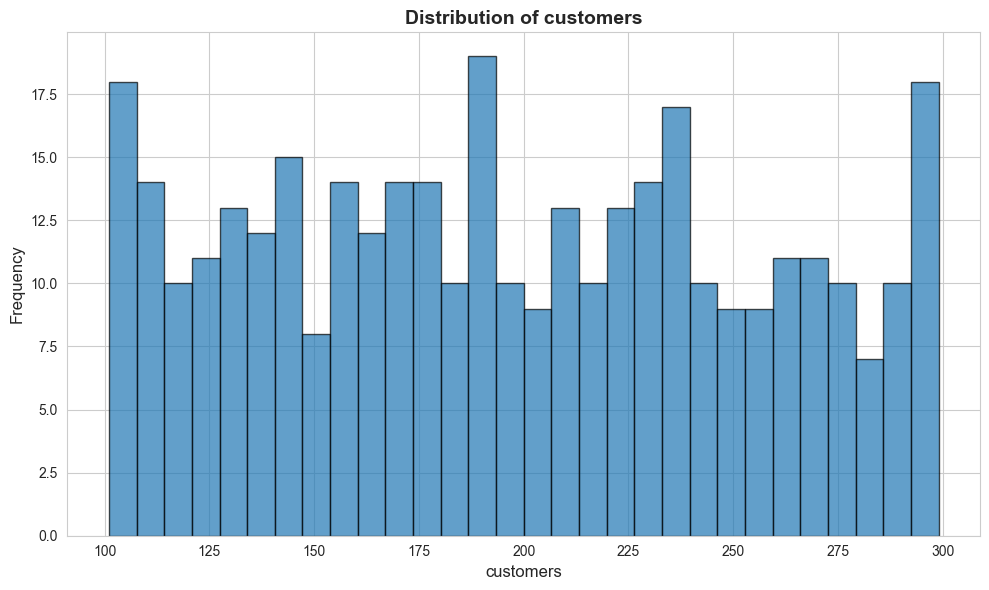

📊 Distribution of conversion


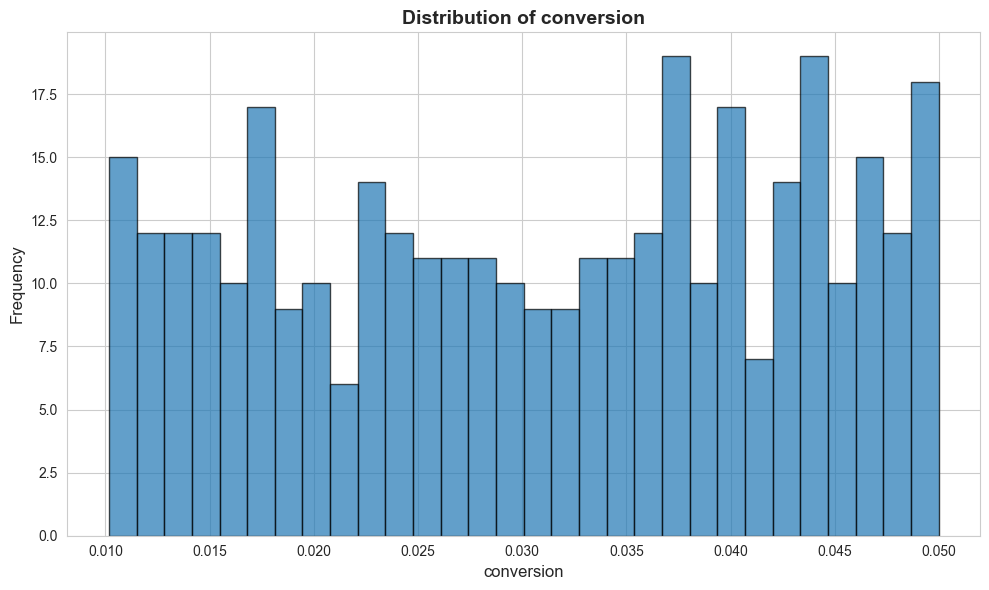

📊 Scatter Plot - revenue vs customers


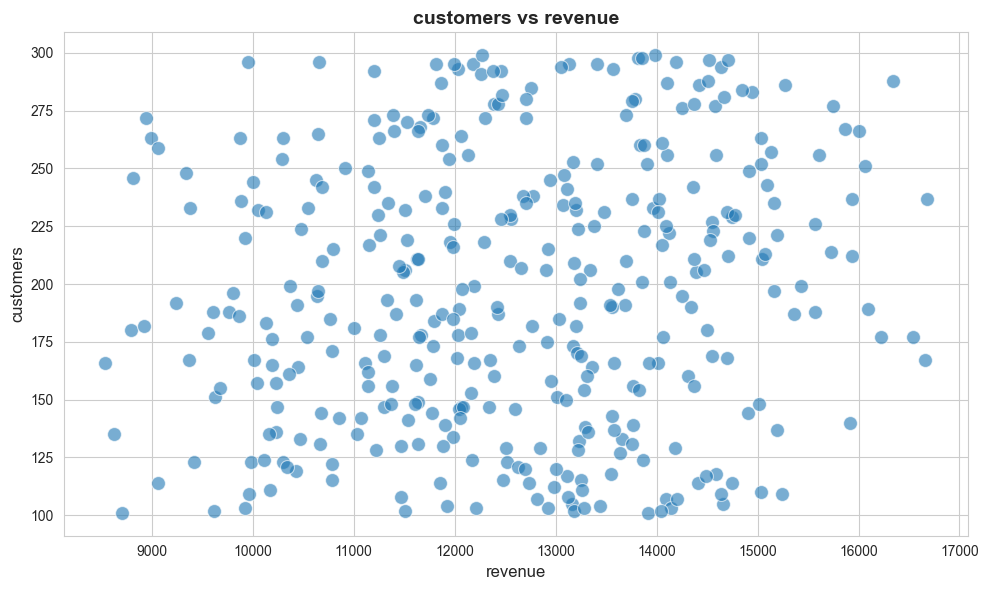

📊 Pairplot Analysis


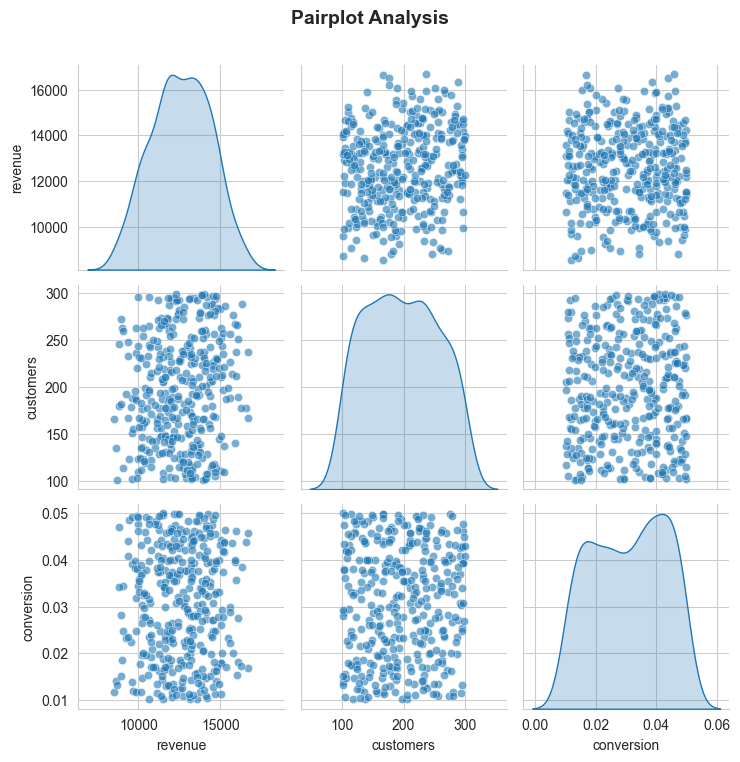


✅ Visualization complete! (6 charts generated)


In [43]:
dv_ts.visualize()

In [45]:
dv_ts.generate_code()

ℹ️  No operations recorded yet. Try using methods like:
   • dv.filter(condition, 'description')
   • dv.sort_values('column')
   • dv.drop_missing(['col1', 'col2'])
   • dv.fill_missing('column', value)

Or generate code for current visualizations:
📊 Suggested Visualizations

1. Distribution of revenue
   Code:
   import matplotlib.pyplot as plt
   
   plt.figure(figsize=(10, 6))
   plt.hist(df['revenue'], bins=30, edgecolor='black', alpha=0.7)
   plt.xlabel('revenue')
   plt.ylabel('Frequency')
   plt.title(f'Distribution of revenue')
   plt.grid(True, alpha=0.3)
   plt.show()

2. Distribution of customers
   Code:
   import matplotlib.pyplot as plt
   
   plt.figure(figsize=(10, 6))
   plt.hist(df['customers'], bins=30, edgecolor='black', alpha=0.7)
   plt.xlabel('customers')
   plt.ylabel('Frequency')
   plt.title(f'Distribution of customers')
   plt.grid(True, alpha=0.3)
   plt.show()

3. Distribution of conversion
   Code:
   import matplotlib.pyplot as plt
   
   plt.figure(figs

''

In [51]:
dv_ts.suggest_charts() #(column='revenue')

📊 Suggested Visualizations

1. Distribution of revenue
   Code:
   import matplotlib.pyplot as plt
   
   plt.figure(figsize=(10, 6))
   plt.hist(df['revenue'], bins=30, edgecolor='black', alpha=0.7)
   plt.xlabel('revenue')
   plt.ylabel('Frequency')
   plt.title(f'Distribution of revenue')
   plt.grid(True, alpha=0.3)
   plt.show()

2. Distribution of customers
   Code:
   import matplotlib.pyplot as plt
   
   plt.figure(figsize=(10, 6))
   plt.hist(df['customers'], bins=30, edgecolor='black', alpha=0.7)
   plt.xlabel('customers')
   plt.ylabel('Frequency')
   plt.title(f'Distribution of customers')
   plt.grid(True, alpha=0.3)
   plt.show()

3. Distribution of conversion
   Code:
   import matplotlib.pyplot as plt
   
   plt.figure(figsize=(10, 6))
   plt.hist(df['conversion'], bins=30, edgecolor='black', alpha=0.7)
   plt.xlabel('conversion')
   plt.ylabel('Frequency')
   plt.title(f'Distribution of conversion')
   plt.grid(True, alpha=0.3)
   plt.show()

4. revenue vs customers
 

[{'title': 'Distribution of revenue',
  'code': "import matplotlib.pyplot as plt\n\nplt.figure(figsize=(10, 6))\nplt.hist(df['revenue'], bins=30, edgecolor='black', alpha=0.7)\nplt.xlabel('revenue')\nplt.ylabel('Frequency')\nplt.title(f'Distribution of revenue')\nplt.grid(True, alpha=0.3)\nplt.show()"},
 {'title': 'Distribution of customers',
  'code': "import matplotlib.pyplot as plt\n\nplt.figure(figsize=(10, 6))\nplt.hist(df['customers'], bins=30, edgecolor='black', alpha=0.7)\nplt.xlabel('customers')\nplt.ylabel('Frequency')\nplt.title(f'Distribution of customers')\nplt.grid(True, alpha=0.3)\nplt.show()"},
 {'title': 'Distribution of conversion',
  'code': "import matplotlib.pyplot as plt\n\nplt.figure(figsize=(10, 6))\nplt.hist(df['conversion'], bins=30, edgecolor='black', alpha=0.7)\nplt.xlabel('conversion')\nplt.ylabel('Frequency')\nplt.title(f'Distribution of conversion')\nplt.grid(True, alpha=0.3)\nplt.show()"},
 {'title': 'revenue vs customers',
  'code': "import matplotlib.p